[Tarea 07] Unidad 03-B | splines cúbicos

Nombre: Ariel Burgos 

CONJUNTO DE EJERCICIOS
1) Dados los puntos (0,1), (1,5), (2,3), determine el spline cúbico.
2) Dados los puntos (−1,1), (1,3), determine el spline cúbico sabiendo que 𝑓
′
(𝑥0) =1, 𝑓′
(𝑥𝑛) = 2. 

In [2]:
import sympy as sym

x = sym.Symbol("x")

def cubic_spline(xs: list[float], ys: list[float], fp0=None, fpn=None):
    points = sorted(zip(xs, ys), key=lambda p: p[0])

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    n = len(xs) - 1
    h = [xs[i + 1] - xs[i] for i in range(n)]

    alpha = [0] * (n + 1)

    # Caso natural
    if fp0 is None or fpn is None:
        for i in range(1, n):
            alpha[i] = (
                3 / h[i] * (ys[i + 1] - ys[i])
                - 3 / h[i - 1] * (ys[i] - ys[i - 1])
            )

        l = [1] + [0] * n
        mu = [0] * (n + 1)
        z = [0] * (n + 1)

        for i in range(1, n):
            l[i] = 2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * mu[i - 1]
            mu[i] = h[i] / l[i]
            z[i] = (alpha[i] - h[i - 1] * z[i - 1]) / l[i]

        l[n] = 1
        z[n] = 0

    # Caso con derivadas dadas
    else:
        alpha[0] = 3 * (ys[1] - ys[0]) / h[0] - 3 * fp0
        alpha[n] = 3 * fpn - 3 * (ys[n] - ys[n - 1]) / h[n - 1]

        for i in range(1, n):
            alpha[i] = (
                3 / h[i] * (ys[i + 1] - ys[i])
                - 3 / h[i - 1] * (ys[i] - ys[i - 1])
            )

        l = [0] * (n + 1)
        mu = [0] * (n + 1)
        z = [0] * (n + 1)

        l[0] = 2 * h[0]
        mu[0] = 0.5
        z[0] = alpha[0] / l[0]

        for i in range(1, n):
            l[i] = 2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * mu[i - 1]
            mu[i] = h[i] / l[i]
            z[i] = (alpha[i] - h[i - 1] * z[i - 1]) / l[i]

        l[n] = h[n - 1] * (2 - mu[n - 1])
        z[n] = (alpha[n] - h[n - 1] * z[n - 1]) / l[n]

    a = ys[:]
    b = [0] * n
    c = [0] * (n + 1)
    d = [0] * n

    c[n] = z[n]

    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j + 1]
        b[j] = (a[j + 1] - a[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

    splines = []

    for j in range(n):
        Sj = a[j] + b[j] * (x - xs[j]) + c[j] * (x - xs[j])**2 + d[j] * (x - xs[j])**3
        splines.append(sym.simplify(Sj))

    return splines

In [3]:
# Ejercicio 1: spline natural
s1 = cubic_spline([0, 1, 2], [1, 5, 3])

for i, s in enumerate(s1):
    print(f"S{i}(x) =", s)


# Ejercicio 2: spline con derivadas dadas
s2 = cubic_spline([-1, 1], [1, 3], fp0=1, fpn=2)

for i, s in enumerate(s2):
    print(f"S{i}(x) =", s)

S0(x) = -1.5*x**3 + 5.5*x + 1
S1(x) = 1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0
S0(x) = 0.25*x**3 + 0.25*x**2 + 0.75*x + 1.75


In [4]:
# ==========================
# Ejercicio 4
# ==========================
xs = [1, 2, 3]
ys = [2, 3, 5]

splines = cubic_spline(xs, ys)

print("Ejercicio 4")
for i, s in enumerate(splines):
    print(f"S{i}(x) =", s)

Ejercicio 4
S0(x) = 0.75*x + 0.25*(x - 1)**3 + 1.25
S1(x) = -0.25*x**3 + 2.25*x**2 - 4.5*x + 5.0


In [5]:
# ==========================
# Ejercicio 5
# ==========================
xs = [0, 1, 2, 3]
ys = [-1, 1, 5, 2]

splines = cubic_spline(xs, ys)

print("\nEjercicio 5")
for i, s in enumerate(splines):
    print(f"S{i}(x) =", s)


Ejercicio 5
S0(x) = 1.0*x**3 + 1.0*x - 1.0
S1(x) = -3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0
S2(x) = 2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0


In [10]:
# Curva 1
x1 = [1, 2, 5, 6, 7, 8, 10, 13, 17]
y1 = [3.0, 3.7, 3.9, 4.2, 5.7, 6.6, 7.1, 6.7, 4.5]
fp1_inicio = 1.0
fp1_final = -0.67

# Curva 2
x2 = [17, 20, 23, 24, 25, 27, 27.7]
y2 = [4.5, 7.0, 6.1, 5.6, 5.8, 5.2, 4.1]
fp2_inicio = 3.0
fp2_final = -4.0

# Curva 3
x3 = [27.7, 28, 29, 30]
y3 = [4.1, 4.3, 4.1, 3.0]
fp3_inicio = 0.33
fp3_final = -1.5

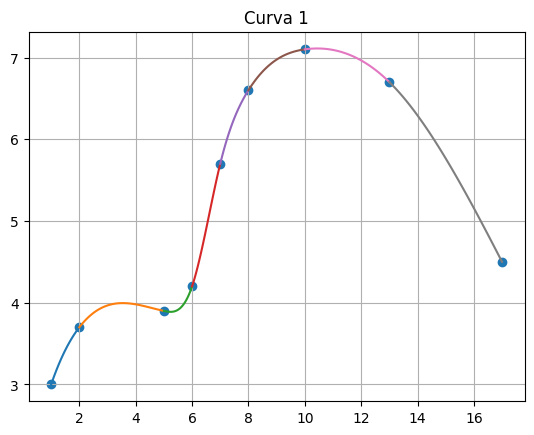

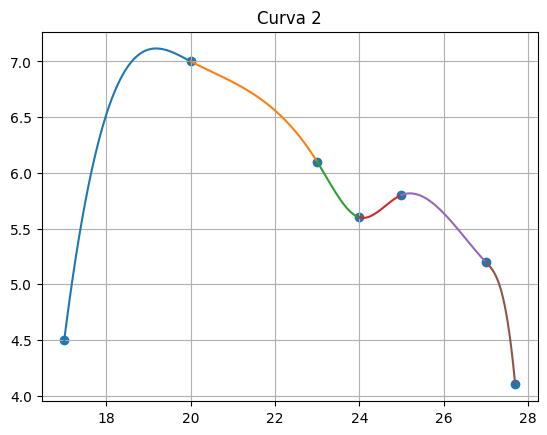

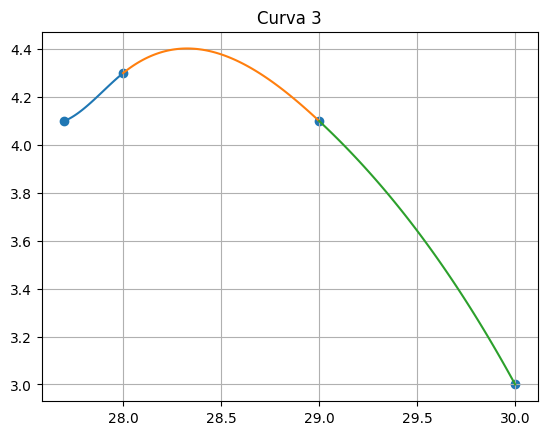

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

x = sym.Symbol("x")

curva1 = cubic_spline(x1, y1, fp1_inicio, fp1_final)
curva2 = cubic_spline(x2, y2, fp2_inicio, fp2_final)
curva3 = cubic_spline(x3, y3, fp3_inicio, fp3_final)

def graficar_spline(xs, ys, splines, nombre):
    for i in range(len(splines)):
        x_vals = np.linspace(xs[i], xs[i+1], 100)
        f = sym.lambdify(x, splines[i], "numpy")
        y_vals = f(x_vals)
        plt.plot(x_vals, y_vals)

    plt.scatter(xs, ys)
    plt.title(nombre)
    plt.grid(True)
    plt.show()

graficar_spline(x1, y1, curva1, "Curva 1")
graficar_spline(x2, y2, curva2, "Curva 2")
graficar_spline(x3, y3, curva3, "Curva 3")